Cumulative Distribution Function (CDF) matching is a method used to remove systematic differences between two sensors or datasets that measure the same variable. For instance, CDF matching is commonly used to rescale satellite soil moisture observations to match in situ observations or model simulations. The method works like a continuous lookup table that converts the readings of one sensor into the readings of another sensor that have the same cumulative probability.

In this exercise we will use daily volumetric water content observations from two sensors installed at the same location and depth:

- The CS655 is a water content reflectometer that measures the relative permittivity of the soil, which is then converted into volumetric water content.

- The CS229 is a heat dissipation sensor encapsulated in a porous ceramic. After a heat pulse, the rate of cooling of the ceramic depends on its water content, which is in equilibrium with the surrounding soil. The sensor estimates the matric potential, which is then converted into volumetric water content.

Because of the different sensing principles and calibrations, the two sensors can show strong systematic differences. Our goal is to correct the signal of the CS229 to match the signal of the CS655:

$$ \theta_{CS655} \approx \theta_{CS229,adj} = \theta_{CS229} + f(\theta_{CS229})$$

where $f$ is a polynomial that describes the difference between the two sensors as a function of the CS229 reading.

In [1]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Read dataset
df = pd.read_csv('../datasets/moisst_cs229_cs655.csv')
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')
df.head()


,date,cs655,cs229
0,2012-04-20,0.297,0.324
1,2012-04-21,0.288,0.310
2,2012-04-22,0.268,0.290
3,2012-04-23,0.247,0.264
4,2012-04-24,0.225,0.235


In [3]:
# Check for missing values
df.isna().sum()


date      0
cs655     0
cs229    32
dtype: int64

In [4]:
# Fill missing values with the last valid observation (forward fill)
df['cs229'] = df['cs229'].ffill()


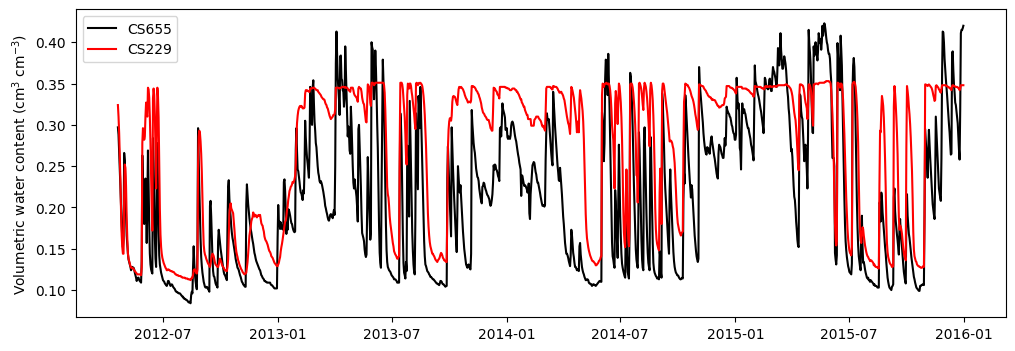

In [5]:
# Plot data
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['cs655'], '-k', label='CS655')
plt.plot(df['date'], df['cs229'], '-r', label='CS229')
plt.ylabel('Volumetric water content (cm$^3$ cm$^{-3}$)')
plt.legend()
plt.show()


In [6]:
# Compute mean bias error and root mean squared difference between sensors
MBE = np.mean(df['cs655'] - df['cs229'])
RMSD = np.sqrt(np.mean((df['cs655'] - df['cs229'])**2))
print('MBE:', round(MBE,3), 'cm^3/cm^3')
print('RMSD:', round(RMSD,3), 'cm^3/cm^3')


MBE: -0.057 cm^3/cm^3
RMSD: 0.082 cm^3/cm^3


## CDF matching

The method consists of the following steps:

1. Sort the observations of each sensor from lowest to highest. Since both sensors have the same number of observations, values at the same position of the sorted arrays have the same cumulative probability.
2. Compute the difference between the sorted CS655 and CS229 values.
3. Fit a polynomial that describes this difference as a function of the sorted CS229 values.
4. Add the difference predicted by the polynomial to the original CS229 observations.

In [7]:
# Sort observations of each sensor
sorted_cs229 = np.sort(df['cs229'])
sorted_cs655 = np.sort(df['cs655'])

# Cumulative probability of each sorted observation
cdf = np.arange(1, df.shape[0]+1) / df.shape[0]


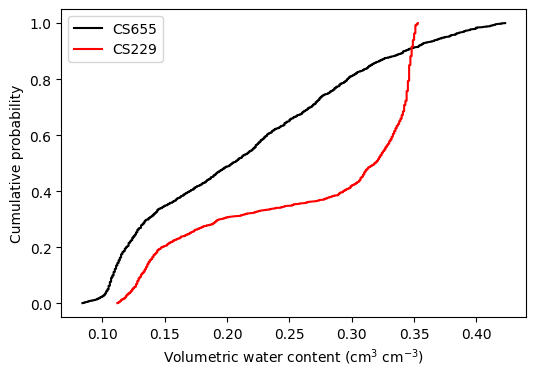

In [8]:
# Plot the cumulative distribution function of each sensor
plt.figure(figsize=(6,4))
plt.plot(sorted_cs655, cdf, '-k', label='CS655')
plt.plot(sorted_cs229, cdf, '-r', label='CS229')
plt.xlabel('Volumetric water content (cm$^3$ cm$^{-3}$)')
plt.ylabel('Cumulative probability')
plt.legend()
plt.show()


In [9]:
# Compute difference between sensors for the same cumulative probability
delta = sorted_cs655 - sorted_cs229

# Fit a third-order polynomial
par = np.polyfit(sorted_cs229, delta, 3)
cdf_fun = np.poly1d(par)
print('Coefficients (highest order first):', np.round(par, 3))


Coefficients (highest order first): [ 96.238 -61.449  11.724  -0.72 ]


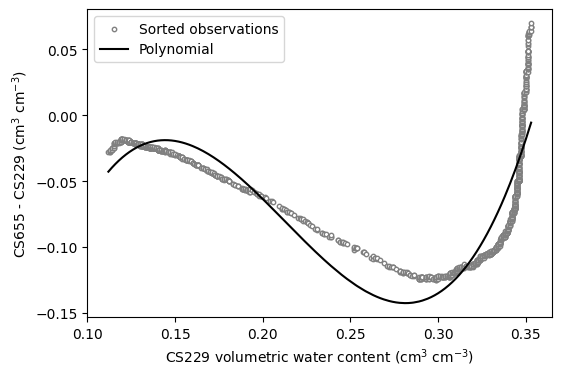

In [10]:
# Plot the difference between sensors and the fitted polynomial
plt.figure(figsize=(6,4))
plt.scatter(sorted_cs229, delta, facecolor='w', edgecolor='gray', s=10, label='Sorted observations')
plt.plot(sorted_cs229, cdf_fun(sorted_cs229), '-k', label='Polynomial')
plt.xlabel('CS229 volumetric water content (cm$^3$ cm$^{-3}$)')
plt.ylabel('CS655 - CS229 (cm$^3$ cm$^{-3}$)')
plt.legend()
plt.show()


In [11]:
# Adjust CS229 observations
df['cs229_adj'] = df['cs229'] + cdf_fun(df['cs229'])


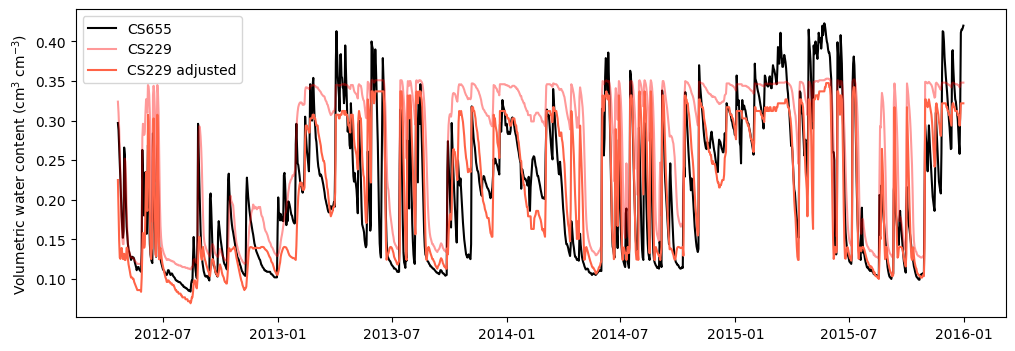

In [12]:
# Plot original and adjusted observations
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['cs655'], '-k', label='CS655')
plt.plot(df['date'], df['cs229'], '-r', alpha=0.4, label='CS229')
plt.plot(df['date'], df['cs229_adj'], '-', color='tomato', label='CS229 adjusted')
plt.ylabel('Volumetric water content (cm$^3$ cm$^{-3}$)')
plt.legend()
plt.show()


In [13]:
# Compute mean bias error and root mean squared difference after the adjustment
MBE_adj = np.mean(df['cs655'] - df['cs229_adj'])
RMSD_adj = np.sqrt(np.mean((df['cs655'] - df['cs229_adj'])**2))
print('MBE:', round(MBE_adj,3), 'cm^3/cm^3')
print('RMSD:', round(RMSD_adj,3), 'cm^3/cm^3')


MBE: 0.0 cm^3/cm^3
RMSD: 0.047 cm^3/cm^3


CDF matching removed the bias between the two sensors and reduced the root mean squared difference by almost half. Note that the method only corrects systematic differences in the distribution of values, so differences in the timing of the observations (for instance, a sensor that responds slower to a rainfall event) remain. Also, in this exercise we fitted and evaluated the polynomial using the same observations, which gives an optimistic estimate of the performance of the method.

## Practice

- Fit the polynomial using only the first half of the record and evaluate the adjustment using the second half. Is the RMSD similar to the one obtained using the entire record?

- Fit polynomials of order 1, 3, and 5. Does a higher order polynomial substantially reduce the RMSD?

## References

Brocca, L., Hasenauer, S., Lacava, T., Melone, F., Moramarco, T., Wagner, W., Dorigo, W., Matgen, P., Martínez-Fernández, J., Llorens, P. and Latron, J., 2011. Soil moisture estimation through ASCAT and AMSR-E sensors: An intercomparison and validation study across Europe. Remote Sensing of Environment, 115(12), pp.3390-3408.

Drusch, M., Wood, E.F. and Gao, H., 2005. Observation operators for the direct assimilation of TRMM microwave imager retrieved soil moisture. Geophysical Research Letters, 32(15).

Reichle, R.H. and Koster, R.D., 2004. Bias reduction in short records of satellite soil moisture. Geophysical Research Letters, 31(19).